## CUSTOMER CHURN CLASSIFICATION 

### Business Problem

Customer retantion is important for business growth particularly operations. it is also more cost effective to retain a customer than trying to acquire a new one. Therefore, customer unsubscribing from Telco heightens the risk of operations and makes it difficult to scale up the business.  This notebook therefore seeks to create a model that will predict future probabilty of a customer leaving Telco services.  



In [34]:
import pandas as pd 
import numpy as np 
 
import matplotlib.pyplot as plt 
import seaborn as sns 



In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score  


The main people conserned with this exercise are the business managers, marketing official and operations management who are concerned wih keeping customers to optimize for recurring profit.  

Prediction from this model can inform marketing strategies and  discount determination.  

In [36]:
# loading the dataset
df = pd.read_csv('Telco_customer_churn.csv')
df.head()




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.describe()



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [39]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [40]:
# UNDERSTANDING THE DATASET 
# Each row represents a customer, and each column contains customer’s attributes described on the column metadata. The column we want to predict is called Churn.

# ustomer churn is our target variable where we want to see how many customers have left the company (Yes) and how many are still customers (No).

# Checking the distribution of target variable

df['Churn'].value_counts(normalize=True)

No     0.73463
Yes    0.26537
Name: Churn, dtype: float64

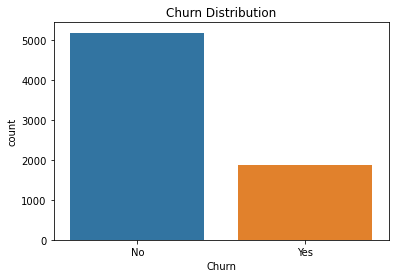

In [41]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

In [42]:
# Data cleaning and preprocessing
# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Remove customerID
df.drop(columns=["customerID"], inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

In [46]:
# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [47]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

### Baseline Model: Logistic Regression
Logistic regression was chosen as the baseline model because it is:
- Interpretable
- Widely used in business contexts
- Well-suited for binary classification

In [48]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

In [49]:
print("TRAINING PERFORMANCE")
print("Recall:", recall_score(y_train, y_train_pred))
print("Accuracy:", accuracy_score(y_train, y_train_pred))

print("\nTEST PERFORMANCE")
print("Recall:", recall_score(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))

TRAINING PERFORMANCE
Recall: 0.551355206847361
Accuracy: 0.80451270383011

TEST PERFORMANCE
Recall: 0.576017130620985
Accuracy: 0.8065984072810012


### Baseline Model Summary
The baseline model provides a reference point for performance.
However, recall can potentially be improved by tuning hyperparameters.The baseline logistic regression model demonstrates consistent performance across training and testing data, indicating good generalization and minimal overfitting.

On the testing dataset, the model achieves:
- **Recall: ~0.58**, meaning it correctly identifies approximately 58% of customers who eventually churn
- **Accuracy: ~0.81**, reflecting strong overall predictive performance driven in part by the majority non-churn class

Given the class imbalance in the target variable, recall is prioritized over accuracy.
While the model performs well overall, it still fails to identify approximately 42% of churners,
which highlights an opportunity for improvement through model tuning or alternative algorithms.

## Tuned Model: Decision Tree Classifier

A decision tree was chosen to:
- Capture non-linear relationships
- Improve recall
- Maintain interpretability

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    dt,
    param_grid,
    scoring="recall",
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 10, 20]},
             scoring='recall')

In [ ]:

grid.best_params_

{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20}

In [ ]:
# Getting the best estimator
best_dt = grid.best_estimator_
best_dt

DecisionTreeClassifier(min_samples_leaf=5, min_samples_split=20,
                       random_state=42)

### Hyperparameter Tuning

To improve the baseline model’s ability to identify customers at risk of churn,
a Decision Tree classifier was tuned using GridSearchCV.
Recall was used as the scoring metric to prioritize correctly identifying churned customers.


In [55]:
# Evaluating the best decision tree model
dt_train_pred = best_dt.predict(X_train)
dt_test_pred = best_dt.predict(X_test)

print("TRAINING PERFORMANCE")
print("Recall:", recall_score(y_train, dt_train_pred))
print("Accuracy:", accuracy_score(y_train, dt_train_pred))

print("\nTEST PERFORMANCE")
print("Recall:", recall_score(y_test, dt_test_pred))
print("Accuracy:", accuracy_score(y_test, dt_test_pred))

TRAINING PERFORMANCE
Recall: 0.6868758915834522
Accuracy: 0.8655669321198332

TEST PERFORMANCE
Recall: 0.47751605995717344
Accuracy: 0.7542662116040956


### Tuned Model Performance: Decision Tree

The tuned decision tree achieved substantially higher recall on the training data;
however, its performance declined noticeably on the testing dataset.
Test recall dropped to approximately 48%, indicating that the model struggles to
generalize to unseen data.

This gap between training and testing performance suggests **overfitting**.
Although the decision tree learned complex patterns in the training data,
those patterns did not translate into improved predictive performance on new observations.

As a result, despite hyperparameter tuning, the decision tree does not outperform
the baseline logistic regression in identifying customers at risk of churn.

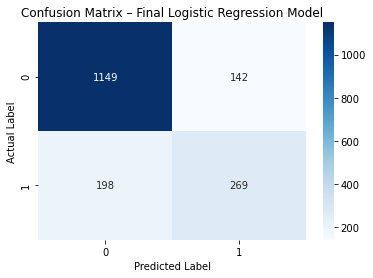

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Final Logistic Regression Model")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix illustrates how the final model’s predictions compare to actual customer outcomes.

- True Positives represent customers correctly identified as likely to churn
- False Negatives represent churned customers the model failed to identify
- False Positives represent customers incorrectly flagged as likely to churn
- True Negatives represent customers correctly identified as not churning

Given the business objective of reducing customer churn, false negatives are the most costly error,
as they represent missed opportunities for retention. While the model does not capture all churned customers,
it identifies a majority of at-risk customers in a consistent and generalizable manner.

## Final Model Selection

Although the tuned decision tree demonstrated strong performance on the training data,
it failed to generalize effectively to the testing dataset.
In contrast, the logistic regression model maintained consistent recall and accuracy
across both training and testing sets.

Given the business objective of reliably identifying customers at risk of churn,
the logistic regression model was selected as the final model due to its stronger
generalization performance and interpretability.

### Key Findings
Key drivers of churn identified by the model include:
- Month-to-month contract types
- Higher monthly charges
- Shorter customer tenure

These findings align with known customer behavior patterns and increase confidence in the model.

## Recommendations

- Prioritize retention campaigns for customers on month-to-month contracts
- Offer targeted discounts to high-risk customers
- Integrate churn predictions into CRM systems for early intervention

### SUMMARY
The tuned decision tree improved recall over the baseline logistic regression while maintaining interpretability.
This makes it suitable for deployment in a business setting where understanding drivers of churn is as important as prediction accuracy.